<a href="https://colab.research.google.com/github/Moquiuti/fundamentos-ia-investigando-algoritmos-abordagens-machine-learning/blob/main/Analisando_tend%C3%AAncias_de_design.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from google.colab import files
uploaded = files.upload()

Saving capas_filmes.zip to capas_filmes.zip


In [4]:
import zipfile
import os

zip_path = 'capas_filmes.zip'  # ajuste se o nome for outro
extract_dir = '/content/capas_filmes'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("Arquivos extraídos em:", extract_dir)
print("Total de arquivos:", len(os.listdir(extract_dir)))

Arquivos extraídos em: /content/capas_filmes
Total de arquivos: 1


In [5]:
import os
import re
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from collections import Counter

In [6]:
def extrair_ano(nome_arquivo):
    match = re.match(r'^(\d{4})', nome_arquivo)
    return int(match.group(1)) if match else None


def cor_predominante_kmeans(imagem_rgb, n_clusters=3):
    pixels = imagem_rgb.reshape(-1, 3)

    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    kmeans.fit(pixels)

    cores = kmeans.cluster_centers_.astype(int)
    labels = kmeans.labels_
    contagem = Counter(labels)

    cluster_mais_comum = contagem.most_common(1)[0][0]
    return cores[cluster_mais_comum]


def extrair_features_imagem(caminho_imagem):
    imagem_bgr = cv2.imread(caminho_imagem)
    if imagem_bgr is None:
        return None

    imagem_bgr = cv2.resize(imagem_bgr, (200, 300))
    imagem_rgb = cv2.cvtColor(imagem_bgr, cv2.COLOR_BGR2RGB)
    imagem_gray = cv2.cvtColor(imagem_bgr, cv2.COLOR_BGR2GRAY)

    # brilho médio
    brilho_medio = np.mean(imagem_gray)

    # contraste simples (desvio padrão)
    contraste = np.std(imagem_gray)

    # densidade de bordas
    bordas = cv2.Canny(imagem_gray, 100, 200)
    densidade_bordas = np.sum(bordas > 0) / bordas.size

    # cor predominante
    cor_pred = cor_predominante_kmeans(imagem_rgb, n_clusters=3)

    return {
        'brilho_medio': brilho_medio,
        'contraste': contraste,
        'densidade_bordas': densidade_bordas,
        'cor_r': cor_pred[0],
        'cor_g': cor_pred[1],
        'cor_b': cor_pred[2]
    }

In [7]:
pasta_imagens = '/content/capas_filmes/capas_filmes'  # ajuste se necessário

dados = []

for arquivo in os.listdir(pasta_imagens):
    caminho = os.path.join(pasta_imagens, arquivo)

    if arquivo.lower().endswith(('.png', '.jpg', '.jpeg')):
        ano = extrair_ano(arquivo)
        if ano is None:
            continue

        features = extrair_features_imagem(caminho)
        if features is None:
            continue

        dados.append({
            'arquivo': arquivo,
            'ano': ano,
            **features
        })

df = pd.DataFrame(dados)
df.head()

,arquivo,ano,brilho_medio,contraste,densidade_bordas,cor_r,cor_g,cor_b
0,2018_busca_implacavel_2.jpg,2018,78.989700,74.158697,0.205483,18,16,16
1,2020_Missao_de_Sobrevivencia.jpg,2020,103.729967,71.433418,0.155083,48,38,35
2,2020_o_macaco.jpg,2020,18.136817,46.076186,0.068717,4,2,2
3,2019_a_origem.jpg,2019,66.947533,72.533229,0.223017,5,12,23


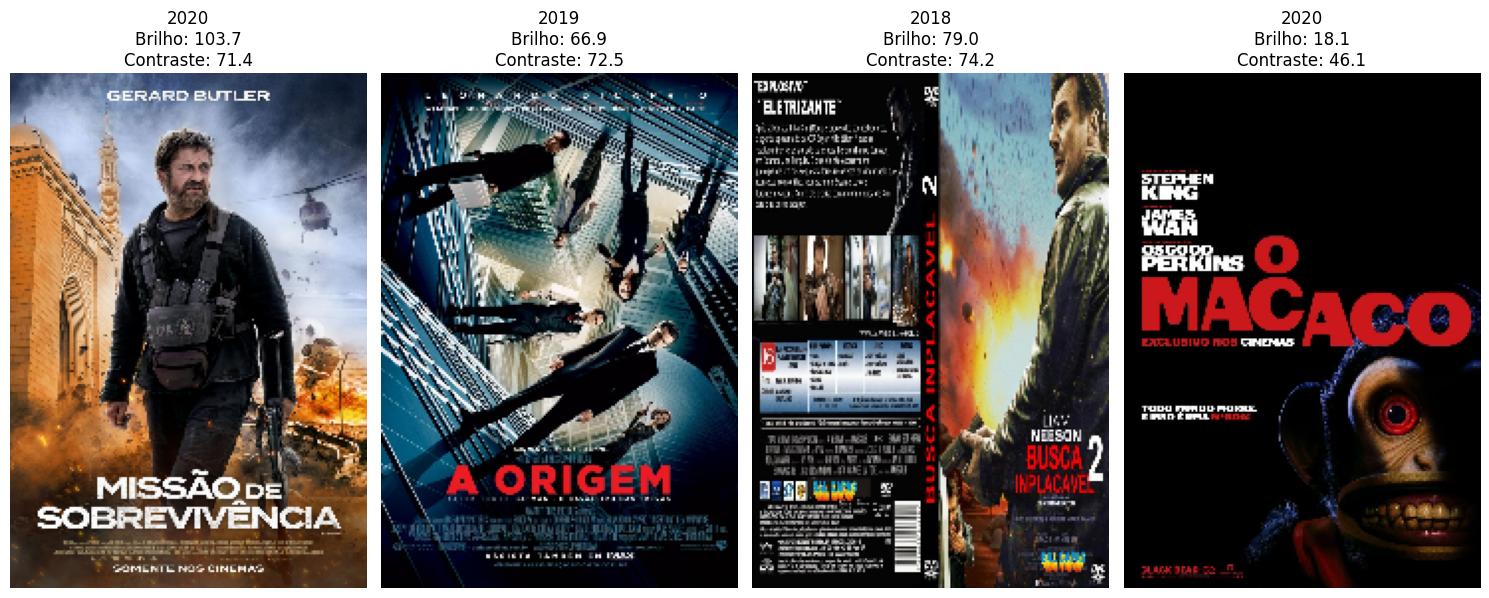

In [8]:
amostra = df.sample(min(5, len(df)), random_state=42)

plt.figure(figsize=(15, 8))

for i, (_, row) in enumerate(amostra.iterrows(), 1):
    caminho = os.path.join(pasta_imagens, row['arquivo'])
    imagem = cv2.imread(caminho)
    imagem = cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB)
    imagem = cv2.resize(imagem, (180, 260))

    plt.subplot(1, len(amostra), i)
    plt.imshow(imagem)
    plt.axis('off')
    plt.title(
        f"{row['ano']}\n"
        f"Brilho: {row['brilho_medio']:.1f}\n"
        f"Contraste: {row['contraste']:.1f}"
    )

plt.tight_layout()
plt.show()

In [9]:
df_ano = df.groupby('ano').agg({
    'brilho_medio': 'mean',
    'contraste': 'mean',
    'densidade_bordas': 'mean',
    'cor_r': 'mean',
    'cor_g': 'mean',
    'cor_b': 'mean'
}).reset_index()

df_ano.head()

,ano,brilho_medio,contraste,densidade_bordas,cor_r,cor_g,cor_b
0,2018,78.989700,74.158697,0.205483,18.0,16.0,16.0
1,2019,66.947533,72.533229,0.223017,5.0,12.0,23.0
2,2020,60.933392,58.754802,0.111900,26.0,20.0,18.5


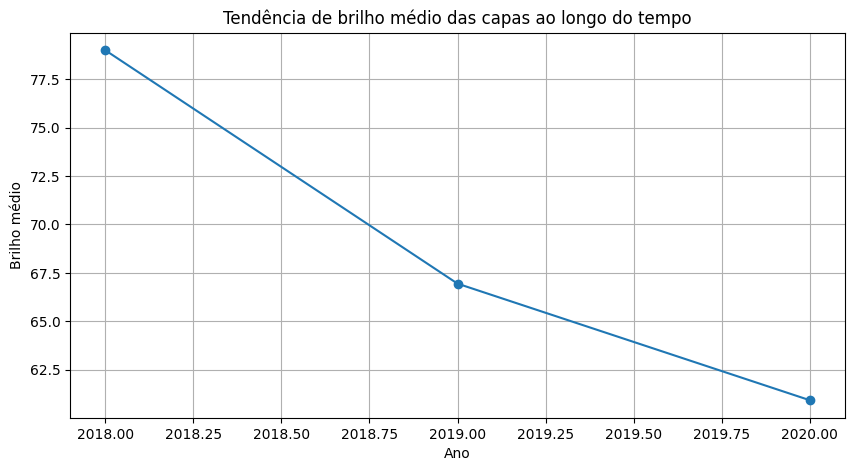

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(df_ano['ano'], df_ano['brilho_medio'], marker='o')
plt.title('Tendência de brilho médio das capas ao longo do tempo')
plt.xlabel('Ano')
plt.ylabel('Brilho médio')
plt.grid(True)
plt.show()

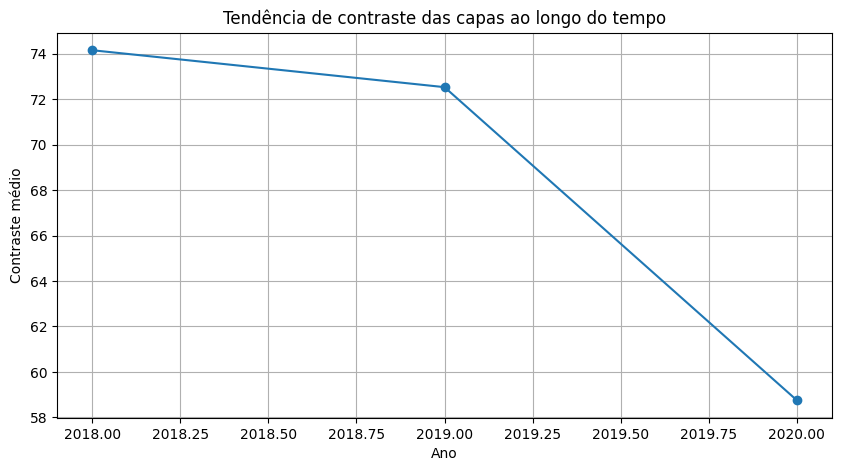

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(df_ano['ano'], df_ano['contraste'], marker='o')
plt.title('Tendência de contraste das capas ao longo do tempo')
plt.xlabel('Ano')
plt.ylabel('Contraste médio')
plt.grid(True)
plt.show()

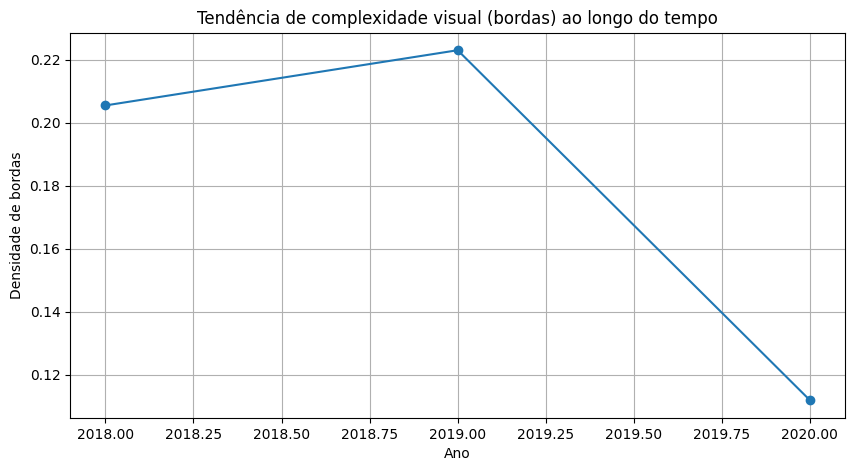

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(df_ano['ano'], df_ano['densidade_bordas'], marker='o')
plt.title('Tendência de complexidade visual (bordas) ao longo do tempo')
plt.xlabel('Ano')
plt.ylabel('Densidade de bordas')
plt.grid(True)
plt.show()

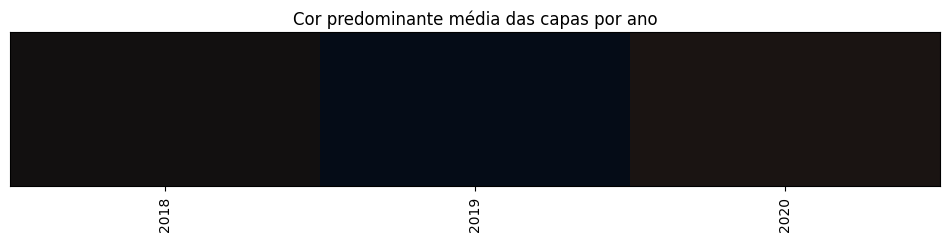

In [13]:
cores_medias = df_ano[['cor_r', 'cor_g', 'cor_b']].values / 255.0

plt.figure(figsize=(12, 2))
plt.imshow([cores_medias], aspect='auto')
plt.yticks([])
plt.xticks(range(len(df_ano['ano'])), df_ano['ano'], rotation=90)
plt.title('Cor predominante média das capas por ano')
plt.show()

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features_cluster = df[['brilho_medio', 'contraste', 'densidade_bordas', 'cor_r', 'cor_g', 'cor_b']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_cluster)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster_visual'] = kmeans.fit_predict(X_scaled)

df[['arquivo', 'ano', 'cluster_visual']].head()

,arquivo,ano,cluster_visual
0,2018_busca_implacavel_2.jpg,2018,1
1,2020_Missao_de_Sobrevivencia.jpg,2020,0
2,2020_o_macaco.jpg,2020,2
3,2019_a_origem.jpg,2019,1


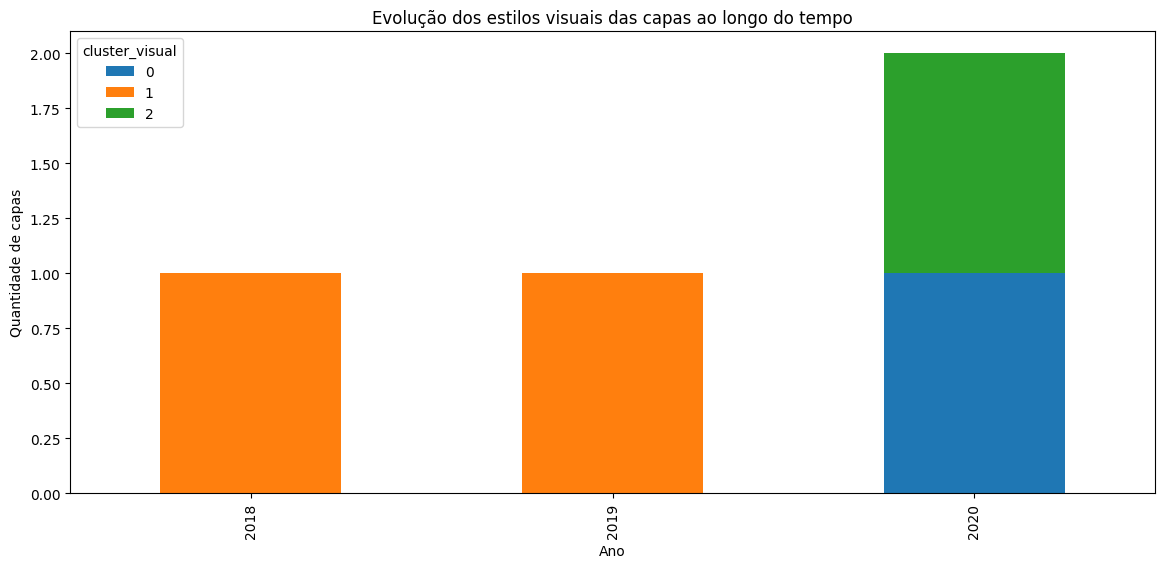

In [15]:
cluster_por_ano = df.groupby(['ano', 'cluster_visual']).size().unstack(fill_value=0)

cluster_por_ano.plot(kind='bar', stacked=True, figsize=(14, 6))
plt.title('Evolução dos estilos visuais das capas ao longo do tempo')
plt.xlabel('Ano')
plt.ylabel('Quantidade de capas')
plt.show()